# Notebook 08: Model Interpretation using SHAP
Goal: Understand which hand landmarks influence predictions


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import joblib

# Load feature-engineered datasets
train_df = pd.read_csv("../notebooks_data/train_fe.csv")
test_df = pd.read_csv("../notebooks_data/test_fe.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (13130, 48)
Test shape: (3283, 48)


In [16]:
# Check column names to identify target column
print("Columns in test dataset:")
for col in test_df.columns:
    print(col)


Columns in test dataset:
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
feat_mean
feat_std
feat_max
feat_min
feat_range
class


In [17]:
# Define target column
TARGET_COLUMN = "class"   # change if needed

# Split features and target
X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_test shape: (3283, 47)
y_test shape: (3283,)


In [18]:
import joblib
from tensorflow.keras.models import load_model

# Load Random Forest (baseline / advanced sklearn model)
baseline_model = joblib.load(
    "../notebooks_data/models_data/advanced/random_forest.pkl"
)

# Load MLP (Keras neural network model)
mlp_model = load_model(
    "../notebooks_data/models_data/baseline/mlp_baseline.hdf5"
)

print("Models loaded successfully")


Models loaded successfully


In [20]:
import pandas as pd
import numpy as np

# Random Forest feature importance
rf_importance = baseline_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

rf_importance_df.head(10)


,Feature,Importance
15,15,0.048808
9,9,0.043812
41,41,0.043512
7,7,0.042453
17,17,0.040677
19,19,0.039251
3,3,0.035024
5,5,0.034451
33,33,0.034330
13,13,0.033944


In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# Convert y_test to numpy array if needed
y_true = y_test.values if hasattr(y_test, "values") else y_test

# Baseline performance
y_pred_base = np.argmax(mlp_model.predict(X_test), axis=1)
baseline_f1 = f1_score(y_true, y_pred_base, average="weighted")

feature_importance = []

# Manual permutation importance
for col in X_test.columns:
    X_permuted = X_test.copy()
    X_permuted[col] = np.random.permutation(X_permuted[col])

    y_pred_perm = np.argmax(mlp_model.predict(X_permuted), axis=1)
    perm_f1 = f1_score(y_true, y_pred_perm, average="weighted")

    importance = baseline_f1 - perm_f1
    feature_importance.append(importance)

# Create importance dataframe
mlp_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

mlp_importance_df.head(10)


103/103 [==============================] - 0s 1ms/step


,Feature,Importance
17,17,0.272865
9,9,0.227093
33,33,0.218166
3,3,0.204361
25,25,0.204343
15,15,0.204032
23,23,0.194513
7,7,0.192510
35,35,0.186734
11,11,0.183586


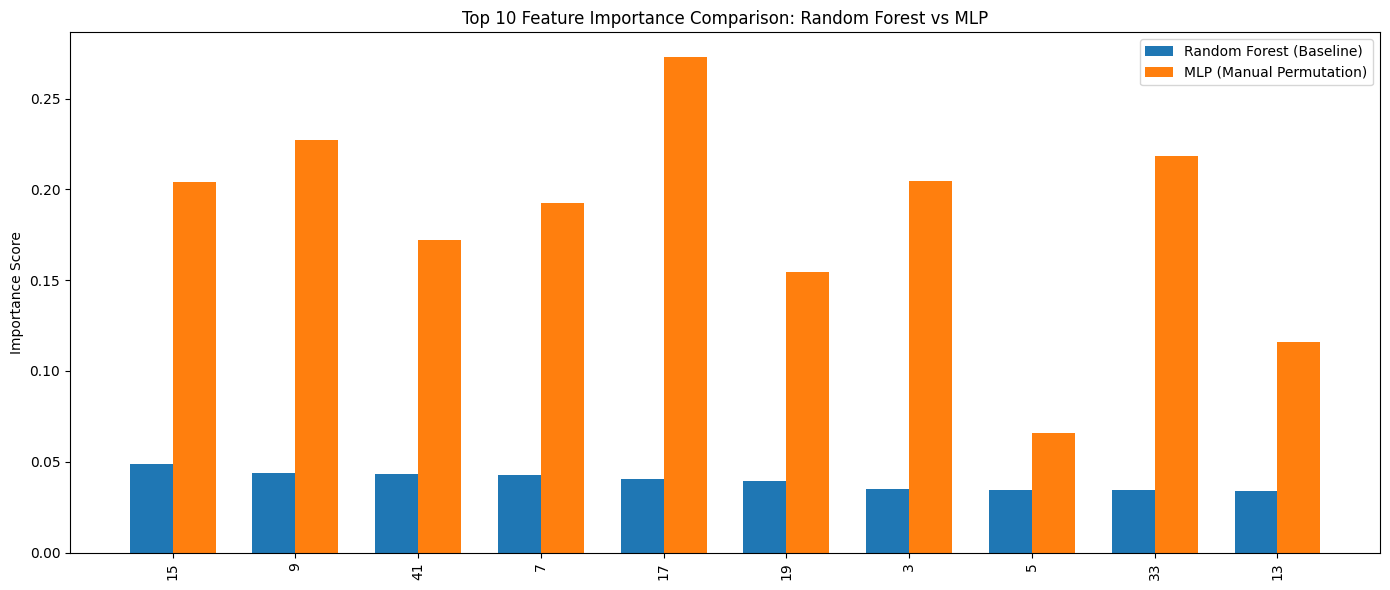

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Take top 10 features from Random Forest
top_features = rf_importance_df["Feature"].head(10)

# Align importance values by feature name
rf_values = rf_importance_df.set_index("Feature").loc[top_features]["Importance"]
mlp_values = mlp_importance_df.set_index("Feature").loc[top_features]["Importance"]

# Bar positions
x = np.arange(len(top_features))
width = 0.35

# Plot comparison
plt.figure(figsize=(14,6))

plt.bar(x - width/2, rf_values, width, label="Random Forest (Baseline)")
plt.bar(x + width/2, mlp_values, width, label="MLP (Manual Permutation)")

plt.xticks(x, top_features, rotation=90)
plt.ylabel("Importance Score")
plt.title("Top 10 Feature Importance Comparison: Random Forest vs MLP")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
import numpy as np

# Select one sample
sample_index = 3

sample = X_test.iloc[[sample_index]]
true_label = y_test.iloc[sample_index]

# Predict probabilities
prediction_probs = mlp_model.predict(sample)

# Get predicted class and confidence
predicted_label = np.argmax(prediction_probs, axis=1)[0]
prediction_confidence = np.max(prediction_probs)

print("True Gesture Label:", true_label)
print("Predicted Gesture Label:", predicted_label)
print("Prediction Confidence:", round(float(prediction_confidence), 3))


1/1 [==============================] - 0s 17ms/step
True Gesture Label: 10
Predicted Gesture Label: 10
Prediction Confidence: 0.85
